# Binary Classification Challenge (Bonus: 2.5 Points for Unit 1)


## Overview  



This challenge is worth **2.5 extra points** for Unit 1.  
Your task is to design and experiment with a **binary classification problem** using datasets generated from `sklearn`.  
You must explore how **data noise**, **loss functions**, and **evaluation metrics** affect model performance and decision boundaries.




### Technical Requirements  



- You **must use the `Architecture` class** provided in class.  
- The model should be a **Logistic Regression** implemented with **PyTorch**.  
- Use at least one dataset generated with:
  - `make_classification`, `make_circles`, or another function from `sklearn.datasets`.  
- Experiment with **different noise levels** in your dataset and analyze how this affects:
  - model convergence,  
  - decision boundary visualization, and  
  - evaluation metrics.


### Experiments to Include  



### 1. Noise Exploration  
- Generate datasets with **different noise levels** (`noise` parameter).  
- Compare visually and numerically how noise influences the results.  
- Discuss the trade-off between separability and generalization.

### 2. Decision Boundary Plot  
- Visualize your model’s **decision boundary** for different noise levels.  
- Provide an interpretation of the shapes and separability observed.  
- Use `matplotlib` to produce clear, well-labeled plots.

### 3. Loss Function Comparison  
- Train your model using both:
  - **`nn.BCELoss`**
  - **`nn.BCEWithLogitsLoss`**
- Explain the difference in how each handles **logits vs probabilities**.  
- Discuss the **numerical stability** of each method.

### 4. Evaluation Metrics  
Compute and report the following metrics for each experiment:
- Accuracy  
- Precision  
- Recall  
- Confusion Matrix  



### Repository Organization  



Your GitHub repository must be **well-structured** and follow good practices:

```bash
📂 your_project_name/
├── data/               # Optional: store generated datasets
├── notebooks/          # Jupyter notebooks or Colab links
├── src/                # Source code if you modularize your solution
├── results/            # Figures, confusion matrices, metrics, etc.
├── README.md           # Detailed documentation (see below)
└── requirements.txt    # Dependencies (if applicable)
```



**`README.md`** must include:
- Project description  
- Instructions on how to execute the code  
- Explanation of your results and observations  
- Comparison of both BCE loss variants  
- Screenshots or plots of **decision boundaries** and **confusion matrices**  
- Link to your presentation video  

---

**Presentation**  

Record a **video (maximum 10 minutes)** using **Loom** or **YouTube** where you:
- Present yourself and introduce your experiment setup  
- Explain your dataset and noise configurations  
- Show and interpret the plots and metrics  
- Conclude with insights on the effects of noise and loss choices  

Include the **video link** in your `README.md`.

---



### ✅ Summary Checklist

| Item | Description | Status |
|------|--------------|--------|
| Dataset | Generated using sklearn (with varying noise levels) | ☐ |
| Model | Logistic Regression using PyTorch | ☐ |
| Architecture | Used the provided `Architecture` class | ☐ |
| Loss Functions | `BCELoss` and `BCEWithLogitsLoss` comparison | ☐ |
| Metrics | Accuracy, Precision, Recall, F1, Confusion Matrix | ☐ |
| Plots | Decision boundary and confusion matrix visuals | ☐ |
| Repository | Well-structured with clear README | ☐ |
| Video | Up to 10 min explaining the full project | ☐ |

---



### Bonus Tip  
To earn full points, focus on:
- **Code clarity** (comments, consistent naming, organized folders)  
- **Reproducibility** (random seeds, clear dependencies)  
- **Interpretation depth** (go beyond the numbers — explain *why* results change)  
- **Visual storytelling** — plots should speak for themselves!







## Synthetic Data Generation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles, make_moons

# For reproducibility
np.random.seed(42)

# Generate different binary classification datasets

# ------------------------------------------------------------
# Dataset 1 - Linearly separable synthetic data
# ------------------------------------------------------------
# make_classification generates data for a classification task
# Key parameters:
# - n_samples: total number of points
# - n_features: number of input features (X columns)
# - n_redundant: number of features that are linear combinations of others
# - n_informative: number of features that actually affect the output
# - n_clusters_per_class: controls how many clusters per class
# - n_classes: number of target classes (default = 2)
# - class_sep: controls how far apart the classes are (larger → easier to separate)
# - random_state: for reproducibility

X1, y1 = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    n_classes=2,          # Number of output classes (binary problem)
    class_sep=1.5,        # Increase for more separable classes
    random_state=42
)

# ------------------------------------------------------------
# Dataset 2 - Concentric circles (nonlinear decision boundary)
# ------------------------------------------------------------
# make_circles creates points arranged in two concentric circles
# Parameters:
# - n_samples: total number of samples
# - factor: ratio between inner and outer circle radii
# - noise: standard deviation of Gaussian noise added to the data
# - random_state: seed for reproducibility
# Always generates 2 classes (inner vs outer circle)

X2, y2 = make_circles(
    n_samples=300,
    factor=0.5,      # Inner circle radius as a fraction of the outer circle
    noise=0.1,       # Add noise to make it more realistic
    random_state=42
)

# ------------------------------------------------------------
# Dataset 3 - Two interleaving moons (nonlinear)
# ------------------------------------------------------------
# make_moons is another classic nonlinear binary dataset
# Parameters:
# - n_samples: total number of points
# - noise: Gaussian noise added to data
# - random_state: for reproducibility

X3, y3 = make_moons(
    n_samples=300,
    noise=0.1,
    random_state=42
)

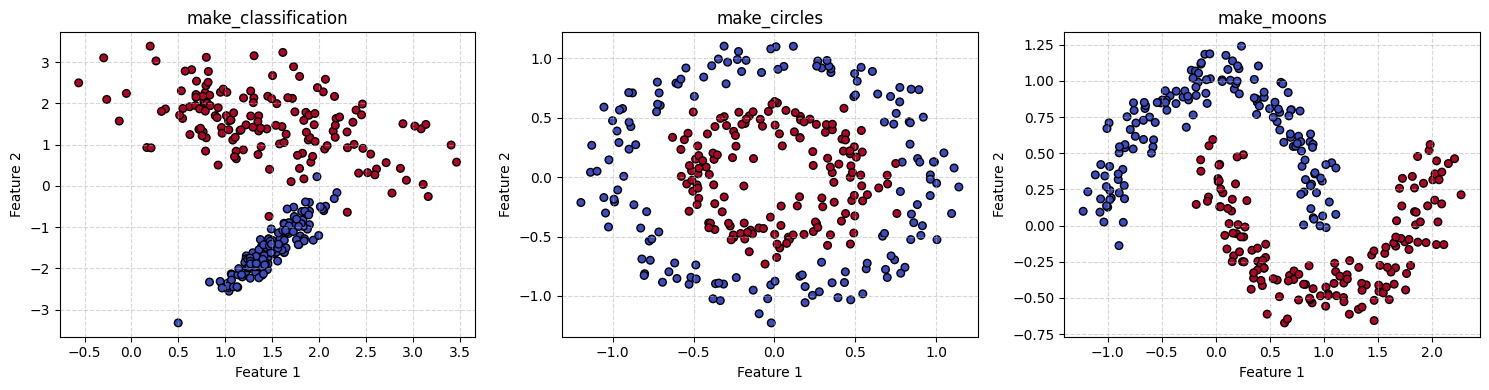

In [2]:
# Plot all datasets in a grid (3 columns)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [(X1, y1, "make_classification"),
            (X2, y2, "make_circles"),
            (X3, y3, "make_moons")]

for ax, (X, y, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=30, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()